# 1. Simple Image Operations

## Table of Contents
1. [Libraries](#libraries)
2. [Loading Images](#loading)
3. [Resizing Images](#resize)
4. [Negative Images](#negative)
5. [Logarithmic Transformation](#log)
6. [Image Binarizer](#bin)
7. [Image Quantizer](#quant)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
from matplotlib import image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import cv2

## Loading Images <a class="anchor" id="loading"></a>

<class 'numpy.ndarray'>


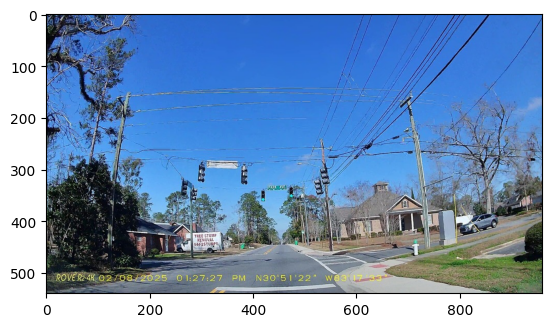

In [2]:
img1 = mpimg.imread('data/image.jpg')
plt.imshow(img1)
print(type(img1))

Look at the shape of this array:

In [3]:
img1.shape

(540, 960, 3)

The image is actually composed of three "layers, or *channels*, for red, green, and blue (RGB) pixel intensities.

Display the same image but this time we'll use another popular Python library for working with images - **cv2**.

numpy.ndarray

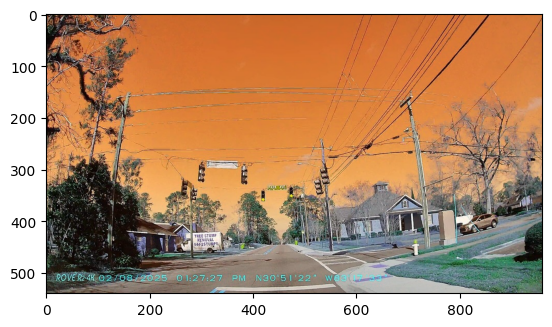

In [4]:
img2 = cv2.imread('data/image.jpg')
plt.imshow(img2)
type(img2)

The trouble is that cv2 loads the array of image data with the channels ordered as blue, green, red (BGR) instead of red, green blue (RGB). 

Let's fix that

AxesImage(shape=(540, 960, 3))


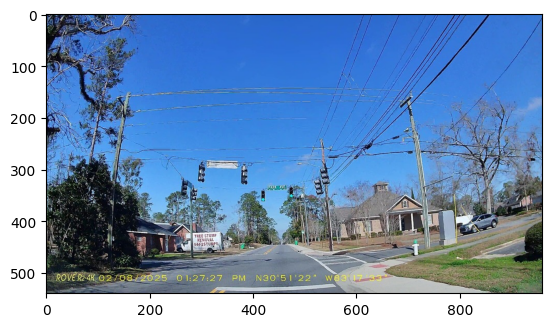

In [5]:
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
print(plt.imshow(img2))

Lastly, one more commonly used library for image processing in Python we should consider - **PIL**:

<class 'PIL.JpegImagePlugin.JpegImageFile'>


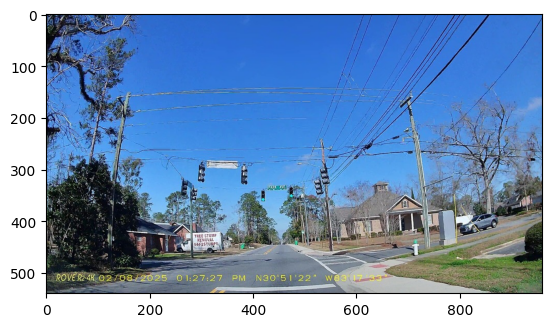

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

img3 = Image.open('data/image.jpg')
plt.imshow(img3)
print(type(img3))

It's easy to convert a PIL JpegImageFile to a numpy array

In [7]:
img3 = np.array(img3)
img3.shape

(540, 960, 3)

Saving a numpy array in an optimized format, should you need to persist images into storage

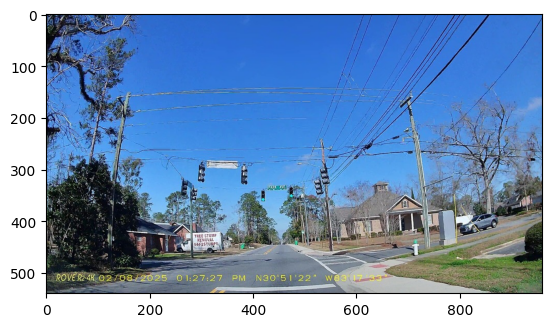

In [8]:
# Save the image
np.save('data/img.npy', img3)

# Load the image
img3 = np.load('data/img.npy')

plt.imshow(img3)

## Resizing an Image <a class="anchor" id="resize"></a>
One of the most common manipulations of an image is to resize it. 

Generally, we want to ensure that all of your training images have consistent dimensions.

Original size: 960 x 540
New size: 200 x 200


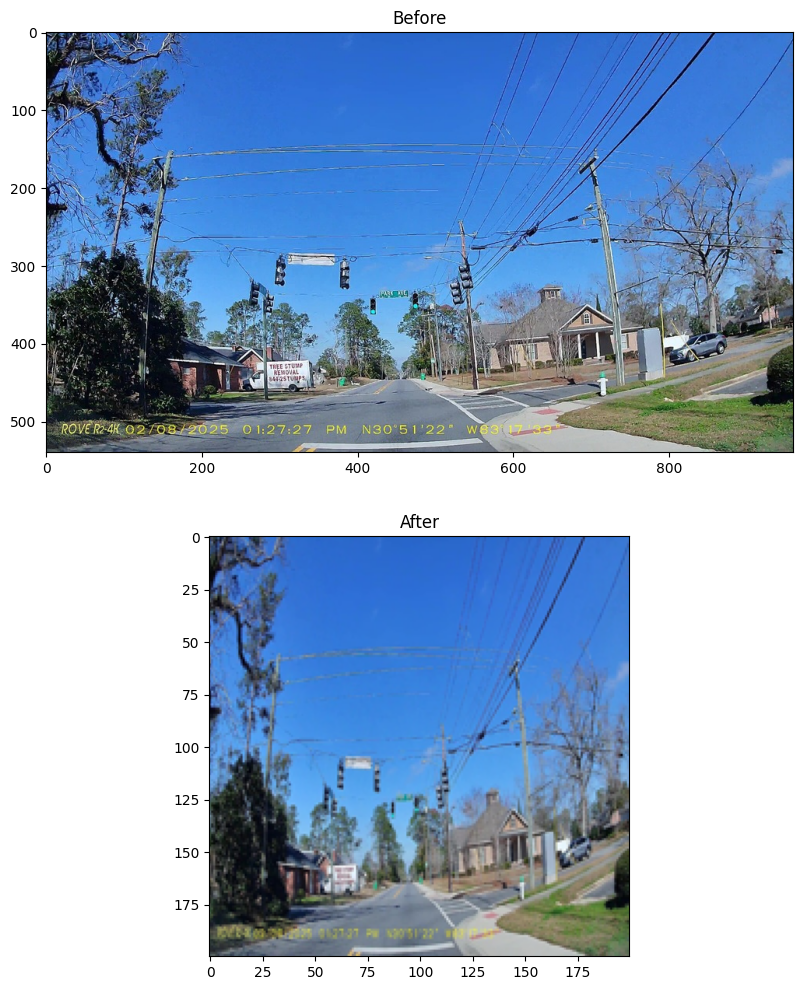

In [9]:
from PIL import Image, ImageOps

# Load the image array into a PIL Image
orig_img = Image.fromarray(img3)

# Get the image size
o_h, o_w = orig_img.size
print('Original size:', o_h, 'x', o_w)

# We'll resize this so it's 200 x 200
target_size = (200,200)
new_img = orig_img.resize(target_size)
n_h, n_w = new_img.size
print('New size:', n_h, 'x', n_w)

# Show the original and resized images
# Create a figure
fig = plt.figure(figsize=(12, 12))

# Subplot for original image
a=fig.add_subplot(2,1,1)
imgplot = plt.imshow(orig_img)
a.set_title('Before')

# Subplot for resized image
a=fig.add_subplot(2,1,2)
imgplot = plt.imshow(new_img)
a.set_title('After')

plt.show()


If we want to resize the image and change its shape without distorting it, we'll need to *scale* the image so that its largest dimension fits our new desired size.

Original size: 960 x 540
Scaled size: 200 x 113
New size: 200 x 200


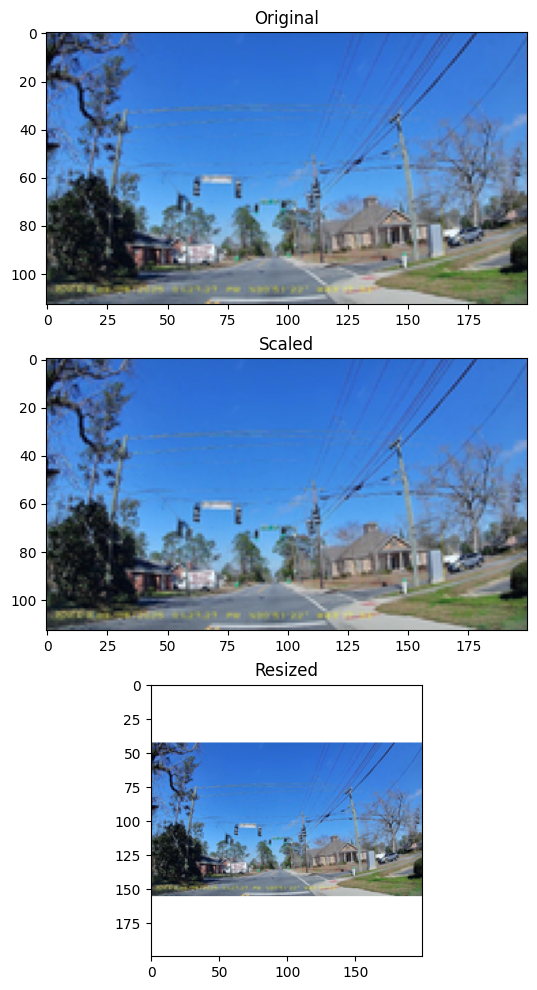

In [10]:
# Get the image size
orig_height, orig_width = orig_img.size
print('Original size:', orig_height, 'x', orig_width)

# We'll resize this so it's 200 x 200
target_size = (200,200)

# Scale the image to the new size using the thumbnail method
scaled_img = orig_img
scaled_img.thumbnail(target_size, Image.LANCZOS)
scaled_height, scaled_width = scaled_img.size
print('Scaled size:', scaled_height, 'x', scaled_width)

# Create a new white image of the target size to be the background
new_img = Image.new("RGB", target_size, (255, 255, 255))

# paste the scaled image into the center of the white background image
new_img.paste(scaled_img, (int((target_size[0] - scaled_img.size[0]) / 2), int((target_size[1] - scaled_img.size[1]) / 2)))
new_height, new_width = new_img.size
print('New size:', new_height, 'x', new_width)

# Show the original and resized images
# Create a figure
fig = plt.figure(figsize=(12, 12))

# Subplot for original image
a=fig.add_subplot(3,1,1)
imgplot = plt.imshow(orig_img)
a.set_title('Original')

# Subplot for scaled image
a=fig.add_subplot(3,1,2)
imgplot = plt.imshow(scaled_img)
a.set_title('Scaled')

# Subplot for resized image
a=fig.add_subplot(3,1,3)
imgplot = plt.imshow(new_img)
a.set_title('Resized')

plt.show()

## Negative Images <a class="anchor" id="negative"></a>

In [11]:
orig_img = cv2.imread('data/image.jpg')
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
img_neg = 255 - orig_img

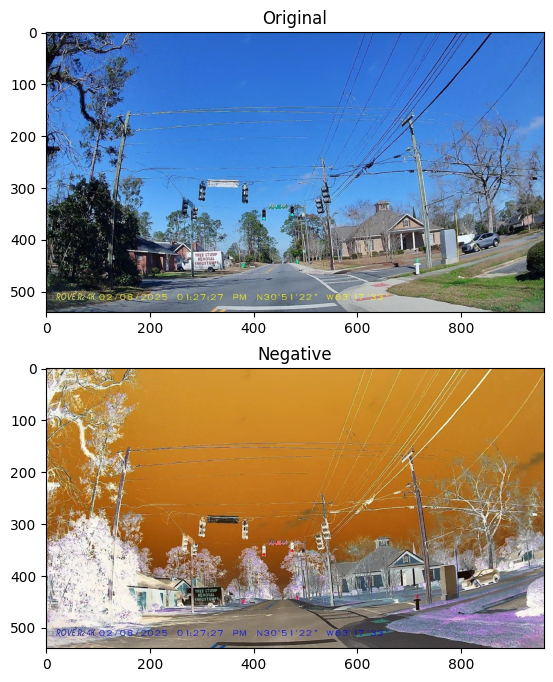

In [12]:
fig = plt.figure(figsize=(8, 8))

# Subplot for original image
a=fig.add_subplot(2,1,1)
imgplot = plt.imshow(orig_img)
a.set_title('Original')

a = fig.add_subplot(2,1,2)
imgplot = plt.imshow(img_neg)
a.set_title('Negative')

plt.show()

## Logarithmic Transformation <a class="anchor" id="log"></a>

$$
S = c * log (1 + r)
$$

where,
- $R$ = input pixel value
- $C$ = scaling constant and
- $S$ = output pixel value

The value of $c$ is chosen such that we get the maximum output value corresponding to the bit size used. So, the formula for calculating $c$  is as follows:

$c = 255 / (log (1 + $ max input pixel value $))$

In [13]:
orig_img = cv2.imread('data/image.jpg')
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

# Apply log transformation method
c = 255 / np.log(1 + np.max(orig_img.astype(np.float64)))
log_img = c * (np.log(orig_img.astype(np.float64) + 1))

# Specify the data type so that
# float value will be converted to int
log_img = np.array(log_img, dtype = np.uint8)

Log transformation of gives actual information by enhancing the image. If we apply this method in an image having higher pixel values then it will enhance the image more and actual information of the image will be lost.

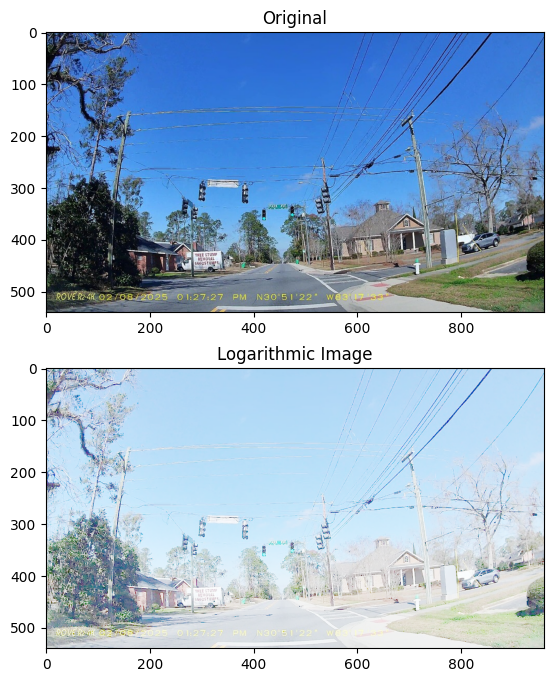

In [14]:
fig = plt.figure(figsize=(8, 8))

# Subplot for original image
a=fig.add_subplot(2,1,1)
imgplot = plt.imshow(orig_img)
a.set_title('Original')

a = fig.add_subplot(2,1,2)
imgplot = plt.imshow(log_img)
a.set_title('Logarithmic Image')

plt.show()

## Image Binarizer (Thresholding) <a class="anchor" id="bin"></a>

Binarize pixels (set pixel values to 0 or 1) according to a threshold.

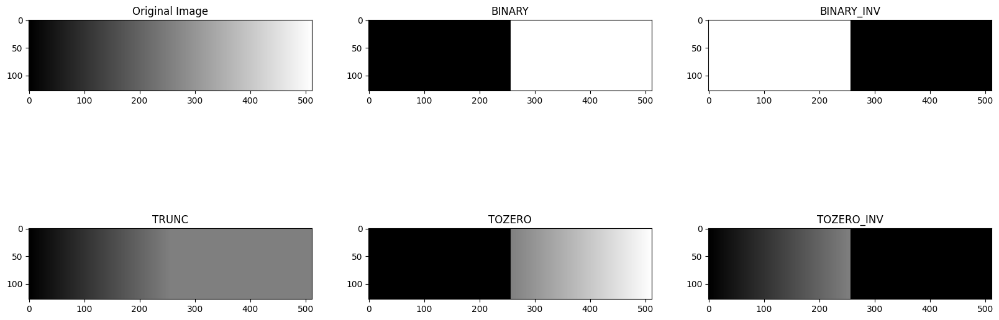

In [15]:
orig_img = cv2.imread('data/linear_gradient.png')
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

ret,thresh1 = cv2.threshold(orig_img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(orig_img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(orig_img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(orig_img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(orig_img,127,255,cv2.THRESH_TOZERO_INV)
 
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [orig_img, thresh1, thresh2, thresh3, thresh4, thresh5]
n = np.arange(6)

fig = plt.figure(figsize=(20, 8))
for i in n:
  plt.subplot(2,3,i+1), plt.imshow(images[i],'gray')
  plt.title(titles[i])

plt.show()

## Image Quantizer  <a class="anchor" id="quant"></a>

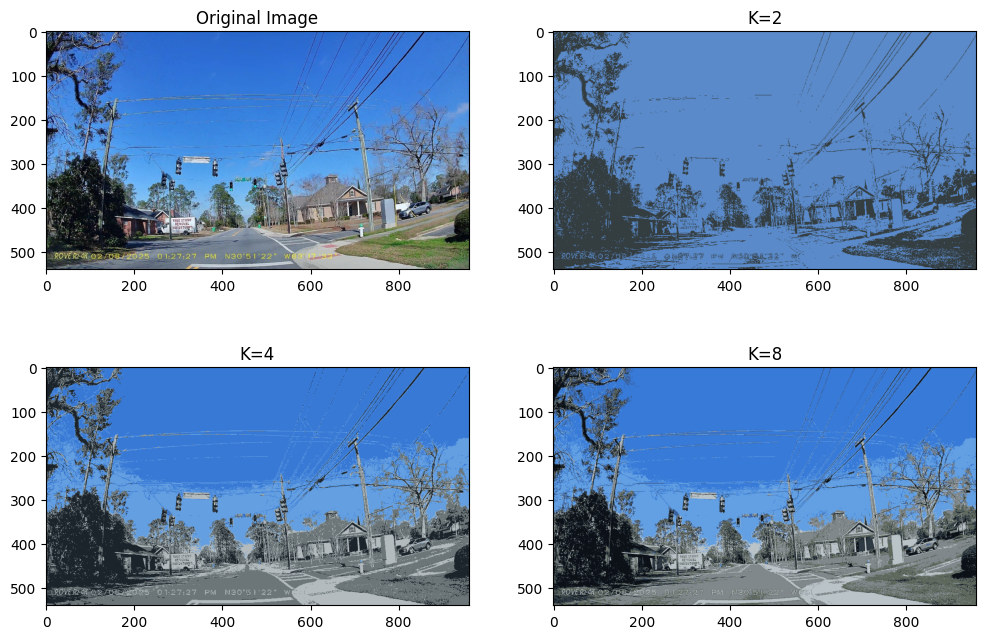

In [16]:
orig_img = cv2.imread('data/image.jpg')

Z = orig_img.reshape((-1,3))

# convert to np.float32
Z = np.float32(Z)

# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
def colorQuant(Z, K, criteria):

   ret,label,center=cv2.kmeans(Z,K,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)
   
   # Now convert back into uint8, and make original image
   center = np.uint8(center)
   res = center[label.flatten()]
   res2 = res.reshape((orig_img.shape))
   return res2
res1 = colorQuant(Z, 2, criteria)
res2 = colorQuant(Z, 5, criteria)
res3 = colorQuant(Z, 8, criteria)

fig = plt.figure(figsize=(12, 8))

plt.subplot(221),plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')

plt.subplot(222),plt.imshow(cv2.cvtColor(res1, cv2.COLOR_BGR2RGB))
plt.title('K=2')

plt.subplot(223),plt.imshow(cv2.cvtColor(res2, cv2.COLOR_BGR2RGB))
plt.title('K=4')

plt.subplot(224),plt.imshow(cv2.cvtColor(res3, cv2.COLOR_BGR2RGB))
plt.title('K=8')

plt.show()

# Ejercicios de la actividad

Los cuatro ejercicios pedidos se agregan a continuación del notebook base. Las imágenes se ejecutan localmente desde la carpeta `data/`
(fotografías de dominio público o con licencia libre; ver `LICENCIAS.md`). Para usar imágenes propias basta con reemplazar los archivos de `data/`
conservando su nombre.

1. [Transformaciones fotométricas para aumento de datos](#ej1)
2. [Negativo de imagen: aplicación en radiología](#ej2)
3. [Corrección gamma: aplicación en imagenología médica y en pantallas](#ej3)
4. [Sustracción de imágenes: detección de cambios y angiografía](#ej4)
5. [Conclusión](#conclusion)

<a id="ej1"></a>
## Ejercicio 1. Transformaciones fotométricas para aumento de datos

**Investigación.** Las transformaciones *píxel a píxel* modifican el valor de cada píxel sin cambiar su posición (a diferencia de las geométricas: giros, recortes, escalado).
Cuando se emplean para *aumentar* un conjunto de entrenamiento (*data augmentation*), simulan cambios de iluminación, de cámara o de color que el modelo
encontrará en el mundo real, sin necesidad de fotografiar de nuevo (Shorten & Khoshgoftaar, 2019). Como la etiqueta de la imagen no cambia (un letrero sigue siendo un letrero),
son una forma barata de mejorar la robustez. Se aplican tres:

| # | Transformación | Modelo | Qué simula |
|---|---|---|---|
| 1 | Brillo y contraste lineal | $g(x,y) = \alpha\, f(x,y) + \beta$ | Cambios de exposición o de iluminación |
| 2 | Perturbación de color en HSV | $H' = H + \Delta h,\; S' = k_s S,\; V' = k_v V$ | Balance de blancos, saturación distinta entre cámaras |
| 3 | Ruido gaussiano aditivo | $g = f + \eta,\; \eta \sim \mathcal{N}(0,\sigma^2)$ | Ruido del sensor con ISO alto o poca luz |

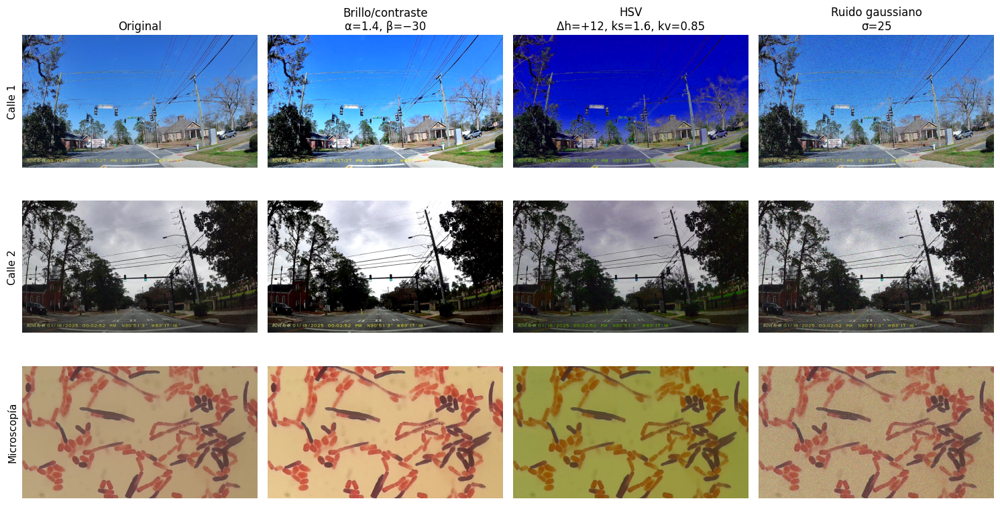

In [17]:
import cv2, numpy as np, matplotlib.pyplot as plt

def leer_rgb(ruta):
    return cv2.cvtColor(cv2.imread(ruta), cv2.COLOR_BGR2RGB)

def brillo_contraste(img, alfa, beta):
    # g = alfa*f + beta, con saturación a [0, 255]
    return np.clip(alfa * img.astype(np.float32) + beta, 0, 255).astype(np.uint8)

def jitter_hsv(img, dh, ks, kv):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)   # H en [0,180) en OpenCV
    hsv[..., 0] = (hsv[..., 0] + dh) % 180
    hsv[..., 1] = np.clip(hsv[..., 1] * ks, 0, 255)
    hsv[..., 2] = np.clip(hsv[..., 2] * kv, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

def ruido_gaussiano(img, sigma, semilla=0):
    rng = np.random.default_rng(semilla)
    return np.clip(img + rng.normal(0, sigma, img.shape), 0, 255).astype(np.uint8)

propias = {"Calle 1": "data/image.jpg", "Calle 2": "data/calle_patterson.jpg", "Microscopía": "data/microscopia.jpg"}
columnas = [("Original", lambda i: i),
            ("Brillo/contraste\nα=1.4, β=−30", lambda i: brillo_contraste(i, 1.4, -30)),
            ("HSV\nΔh=+12, ks=1.6, kv=0.85", lambda i: jitter_hsv(i, 12, 1.6, 0.85)),
            ("Ruido gaussiano\nσ=25", lambda i: ruido_gaussiano(i, 25))]

fig, ejes = plt.subplots(len(propias), len(columnas), figsize=(15, 8.2))
for r, (nombre, ruta) in enumerate(propias.items()):
    img = leer_rgb(ruta)
    for c, (titulo, f) in enumerate(columnas):
        ejes[r, c].imshow(f(img)); ejes[r, c].axis("off")
        if r == 0: ejes[r, c].set_title(titulo)
    ejes[r, 0].text(-0.02, 0.5, nombre, transform=ejes[r, 0].transAxes, rotation=90, ha="right", va="center", fontsize=11)
plt.tight_layout(); plt.show()

In [18]:
# Estadísticas: cómo cambia la distribución de intensidades con cada transformación (imagen "Calle 1")
img = leer_rgb("data/image.jpg")
filas = []
for titulo, f in columnas:
    g = cv2.cvtColor(f(img), cv2.COLOR_RGB2GRAY).astype(float)
    filas.append((titulo.replace("\n", " "), g.mean(), g.std(), (g >= 250).mean() * 100, (g <= 5).mean() * 100))
print(f"{'Transformación':46s} {'media':>7s} {'desv.':>7s} {'%saturado':>10s} {'%negro':>7s}")
for t, m, s, sat, neg in filas:
    print(f"{t:46s} {m:7.1f} {s:7.1f} {sat:10.2f} {neg:7.2f}")

Transformación                                   media   desv.  %saturado  %negro
Original                                         114.8    42.5       0.12    0.95
Brillo/contraste α=1.4, β=−30                    129.3    55.5       1.46    5.71
HSV Δh=+12, ks=1.6, kv=0.85                       51.6    41.2       0.00    3.05
Ruido gaussiano σ=25                             114.7    44.5       0.11    1.23


**Discusión.** El brillo/contraste aumenta la desviación estándar (más contraste) pero desplaza la media y crea píxeles saturados o negros que ya no se pueden recuperar;
el ruido gaussiano casi no cambia la media, pero altera la textura fina (importante para redes que dependen de bordes); y la perturbación HSV cambia el color sin tocar las formas.
Estas variantes obligan al modelo a apoyarse en la *forma* del objeto y no en un color o una exposición concretos. Hay que elegir parámetros verosímiles:
un ruido de σ=25 es plausible para una foto nocturna, pero en una imagen médica podría ocultar una lesión real y cambiar el diagnóstico, así que en ese dominio el aumento fotométrico se usa con más cautela.

<a id="ej2"></a>
## Ejercicio 2. Negativo de imagen: aplicación en radiología

**Investigación.** El negativo de una imagen con $L$ niveles es $s = L - 1 - r$. Gonzalez y Woods (2018) señalan que es especialmente adecuado para *realzar detalles blancos o grises
inmersos en regiones oscuras* de una imagen, en particular cuando las zonas oscuras dominan; su ejemplo es una mamografía digital, donde las lesiones pequeñas son más fáciles de ver en la versión negativa.
Otra aplicación con valor específico es la **digitalización de películas fotográficas y radiográficas**: el escáner captura el negativo y hay que invertirlo para obtener la imagen positiva.

**Demo.** Se invierte una radiografía de tórax (CC0) y se compara una región del campo pulmonar, donde las estructuras finas (vasos y bronquios) son de bajo contraste.

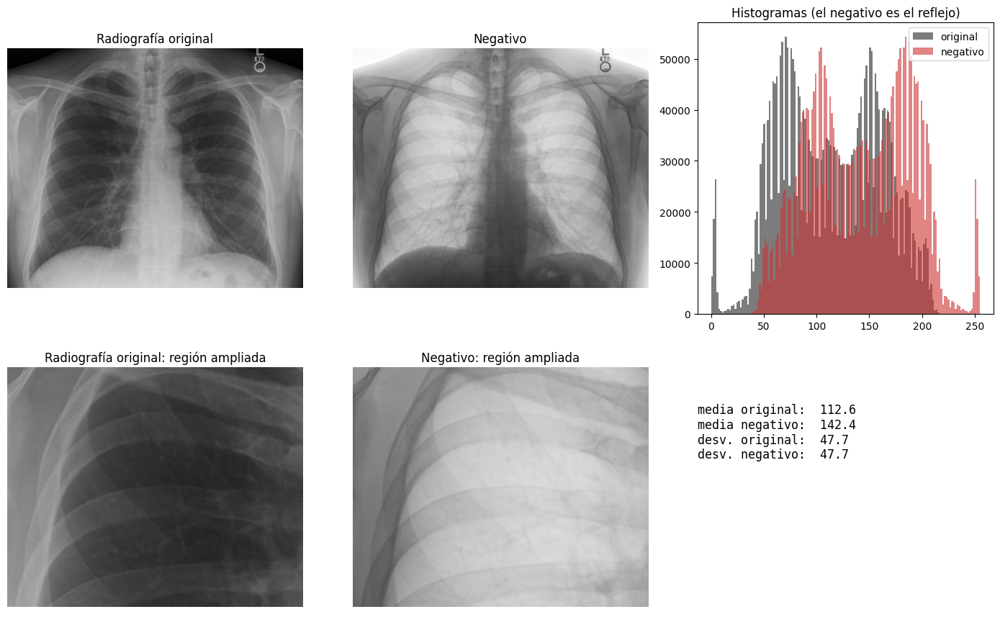

In [19]:
rx = cv2.imread("data/radiografia_torax.jpg", cv2.IMREAD_GRAYSCALE)
neg = 255 - rx
h, w = rx.shape
roi = (slice(int(h*0.18), int(h*0.50)), slice(int(w*0.10), int(w*0.42)))   # campo pulmonar derecho del paciente

fig, ejes = plt.subplots(2, 3, figsize=(14, 9))
for c, (t, im) in enumerate((("Radiografía original", rx), ("Negativo", neg))):
    ejes[0, c].imshow(im, cmap="gray", vmin=0, vmax=255); ejes[0, c].set_title(t); ejes[0, c].axis("off")
    ejes[1, c].imshow(im[roi], cmap="gray", vmin=0, vmax=255); ejes[1, c].set_title(f"{t}: región ampliada"); ejes[1, c].axis("off")
ejes[0, 2].hist(rx.ravel(), 128, color="#444", alpha=.7, label="original"); ejes[0, 2].hist(neg.ravel(), 128, color="#c33", alpha=.6, label="negativo")
ejes[0, 2].set_title("Histogramas (el negativo es el reflejo)"); ejes[0, 2].legend()
ejes[1, 2].axis("off")
ejes[1, 2].text(0, .6, f"media original:  {rx.mean():.1f}\nmedia negativo:  {neg.mean():.1f}\n"
                       f"desv. original:  {rx.std():.1f}\ndesv. negativo:  {neg.std():.1f}", family="monospace", fontsize=12)
plt.tight_layout(); plt.show()

**Discusión.** La desviación estándar no cambia (el negativo solo refleja el histograma), de modo que no hay más información: lo que mejora es la *percepción*.
El ojo humano discrimina mejor pequeñas diferencias de luminancia en fondos claros que en fondos muy oscuros, por lo que algunos especialistas prefieren revisar ciertas regiones en negativo.
Por eso el negativo es útil como paso de visualización, no como algoritmo de mejora de la información.

<a id="ej3"></a>
## Ejercicio 3. Corrección gamma

**Investigación.** La transformación de potencia $s = c\, r^{\gamma}$ (con $r \in [0,1]$) tiene dos usos prácticos. (1) **Compensación de dispositivos de visualización:** los monitores
reproducen la intensidad con una respuesta aproximadamente $V^{2.2}$, por lo que las imágenes se *codifican* con el exponente inverso; sin esa corrección se verían demasiado oscuras.
(2) **Mejora de contraste en imágenes oscuras o lavadas:** con $\gamma < 1$ se expanden las intensidades bajas (se ven detalles en sombras); con $\gamma > 1$ se comprimen las bajas y se expanden las altas.
Gonzalez y Woods (2018) lo ilustran con una resonancia magnética de columna y una imagen aérea lavada. Aquí se aplica a una resonancia cerebral T1 con contraste, cuya materia gris y estructuras profundas quedan en la zona oscura del histograma.

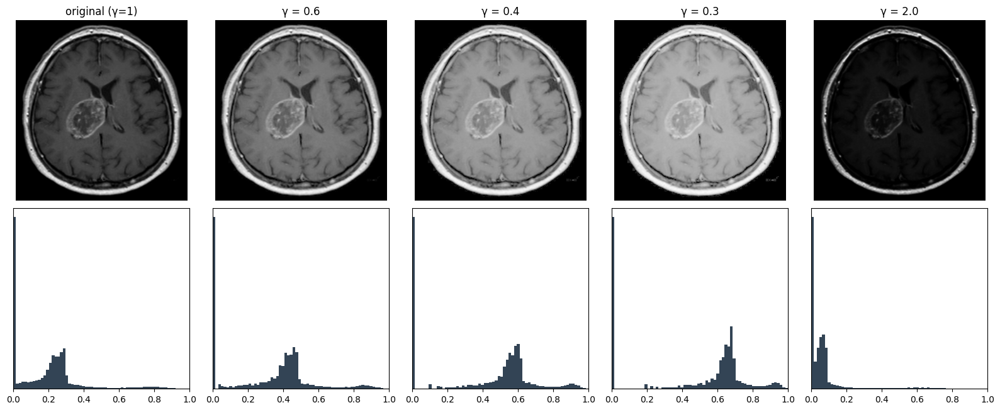

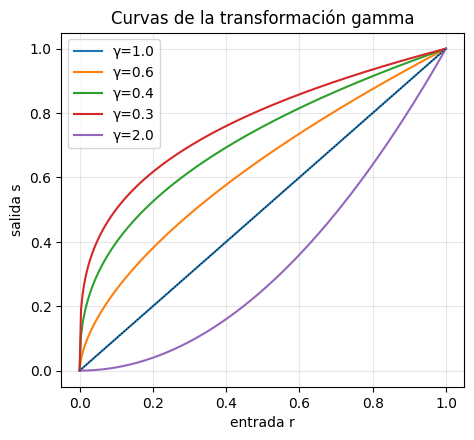

In [20]:
mri = cv2.imread("data/resonancia_cerebro.jpg", cv2.IMREAD_GRAYSCALE)

def gamma(img, g, c=1.0):
    return np.clip(c * (img / 255.0) ** g, 0, 1)

gammas = [1.0, 0.6, 0.4, 0.3, 2.0]
fig, ejes = plt.subplots(2, len(gammas), figsize=(16, 6.6))
for c, g in enumerate(gammas):
    out = gamma(mri, g)
    ejes[0, c].imshow(out, cmap="gray", vmin=0, vmax=1); ejes[0, c].axis("off")
    ejes[0, c].set_title("original (γ=1)" if g == 1 else f"γ = {g}")
    ejes[1, c].hist(out.ravel(), 64, color="#345"); ejes[1, c].set_yticks([]); ejes[1, c].set_xlim(0, 1)
plt.tight_layout(); plt.show()

r = np.linspace(0, 1, 256)
plt.figure(figsize=(5.2, 4.6))
for g in gammas: plt.plot(r, r**g, label=f"γ={g}")
plt.plot(r, r, "k:", lw=.8); plt.xlabel("entrada r"); plt.ylabel("salida s"); plt.title("Curvas de la transformación gamma"); plt.legend(); plt.grid(alpha=.3); plt.show()

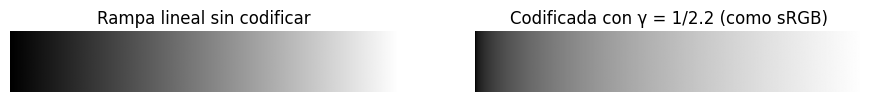

In [21]:
# Demo de la compensación de pantalla: una rampa lineal de luz se ve "correcta" solo si se codifica con γ≈1/2.2
rampa = np.tile(np.linspace(0, 1, 512), (80, 1))
codificada = rampa ** (1 / 2.2)
fig, ejes = plt.subplots(1, 2, figsize=(11, 2.2))
ejes[0].imshow(rampa, cmap="gray", vmin=0, vmax=1); ejes[0].set_title("Rampa lineal sin codificar"); ejes[0].axis("off")
ejes[1].imshow(codificada, cmap="gray", vmin=0, vmax=1); ejes[1].set_title("Codificada con γ = 1/2.2 (como sRGB)"); ejes[1].axis("off")
plt.show()

**Discusión.** Con γ=0.4 se revela la textura de los tejidos que en la imagen original casi no se distingue, a costa de perder contraste en las zonas ya claras (el tumor comienza a saturarse);
con γ=2 ocurre lo contrario. La elección del exponente depende de la tarea: no existe un valor universal. Es la razón de que los sistemas de visión suelan normalizar la iluminación antes de aplicar un detector.

<a id="ej4"></a>
## Ejercicio 4. Sustracción de imágenes

**Investigación.** La diferencia $g(x,y) = f_1(x,y) - f_2(x,y)$ elimina lo que es común a ambas imágenes y deja únicamente lo que cambió. Dos aplicaciones clásicas:
- **Detección de cambios / movimiento** en videovigilancia y tráfico: se resta un fondo de referencia del fotograma actual y se umbraliza (Gonzalez & Woods, 2018).
- **Angiografía por sustracción digital (DSA):** se resta una imagen "máscara" (antes de inyectar contraste) de la imagen "en vivo" (con contraste), de modo que el hueso y los tejidos desaparecen y solo quedan los vasos (Gonzalez & Woods, 2018, modo máscara).

**Demo.** Detección de cambios con dos fotogramas. Como aquí no hay un video, el segundo fotograma se construye con la misma escena (calle, CC0) más una pieza recortada que se desplaza,
y con ruido gaussiano distinto en cada toma para imitar el sensor. Así se conoce la verdad: dónde está realmente el objeto.

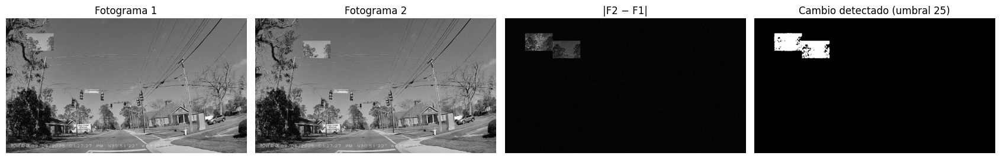

IoU entre la máscara detectada y las dos posiciones reales del objeto: 0.90


In [22]:
base = cv2.cvtColor(cv2.imread("data/image.jpg"), cv2.COLOR_BGR2GRAY).astype(np.float32)
H, W = base.shape
rng = np.random.default_rng(3)

# "objeto" = un parche real de la escena (una zona con detalle) pegado en dos posiciones
parche = base[int(H*.62):int(H*.62)+70, int(W*.30):int(W*.30)+110].copy()
def fotograma(x, y):
    f = base.copy(); f[y:y+parche.shape[0], x:x+parche.shape[1]] = parche
    return np.clip(f + rng.normal(0, 4, f.shape), 0, 255)

f1 = fotograma(80, 60)      # objeto arriba a la izquierda
f2 = fotograma(190, 90)     # el objeto se movió
diff = np.abs(f2 - f1)
mascara = (cv2.GaussianBlur(diff, (5, 5), 0) > 25).astype(np.uint8)
mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))   # quita puntos de ruido aislados

fig, ejes = plt.subplots(1, 4, figsize=(17, 3.6))
for a, im, t in zip(ejes, (f1, f2, diff, mascara), ("Fotograma 1", "Fotograma 2", "|F2 − F1|", "Cambio detectado (umbral 25)")):
    a.imshow(im, cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

verdad = np.zeros_like(mascara)
for (x, y) in ((80, 60), (190, 90)): verdad[y:y+parche.shape[0], x:x+parche.shape[1]] = 1
inter = (mascara & verdad).sum(); union = (mascara | verdad).sum()
print(f"IoU entre la máscara detectada y las dos posiciones reales del objeto: {inter/union:.2f}")

**Discusión.** La sustracción separa lo que cambió, pero es sensible al ruido: sin umbral ni suavizado aparecen puntos por todo el fondo, y por eso se combina con filtrado y apertura morfológica.
Además el resultado marca *ambas* posiciones (donde estaba y donde está el objeto), no solo la nueva. En una angiografía real la máscara y la imagen en vivo deben estar perfectamente alineadas: un pequeño movimiento del paciente
genera artefactos que obligan a registrar las imágenes antes de restarlas.

<a id="conclusion"></a>
## Conclusión

- Las operaciones píxel a píxel son las más simples del procesamiento digital de imágenes y, aun así, sirven para tareas tan distintas como **generar variantes de entrenamiento** (ejercicio 1),
  **mejorar la lectura de una radiografía** (2), **compensar la respuesta de una pantalla o realzar tejidos oscuros** (3) y **detectar cambios** (4).
- Ninguna de ellas agrega información: reasignan valores. El negativo conserva la desviación estándar exactamente; gamma y el brillo/contraste solo desplazan la información a otra parte del histograma, y pueden perderla si saturan.
- La calidad del resultado depende siempre del **histograma de partida**: una transformación útil en una imagen oscura (γ<1) daña una imagen ya brillante.
- Para conjuntos de datos, el aumento fotométrico debe conservar la etiqueta y ser verosímil; en imagen médica se usa con más cautela que en fotografía general.
- Hallazgos sobre el notebook base (ambos afectan también al Colab actual): (a) `Image.ANTIALIAS` ya no existe en Pillow reciente y se cambió por `Image.LANCZOS`;
  (b) con NumPy 2 la suma `np.max(orig_img) + 1` sobre `uint8` desborda (255 + 1 = 0), el logaritmo de 0 es infinito y la imagen de la transformación logarítmica salía completamente negra;
  se corrigió convirtiendo a `float64` antes de aplicar el logaritmo.

## Referencias

- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4.ª ed.). Pearson.
- Shorten, C., & Khoshgoftaar, T. M. (2019). A survey on image data augmentation for deep learning. *Journal of Big Data, 6*, Artículo 60. https://doi.org/10.1186/s40537-019-0197-0
- Bradski, G. (2000). The OpenCV library. *Dr. Dobb's Journal of Software Tools*, 25(11), 120–123.
- OpenCV. (s. f.). *Histogram equalization* [Tutorial]. https://docs.opencv.org/3.4/d4/d1b/tutorial_histogram_equalization.html
- Imágenes: ver `LICENCIAS.md` (Wikimedia Commons: Rivera, Stillwaterising, Hellerhoff, Arnatbio, Chaurasiya; licencias CC0, CC BY-SA).